In [2]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

C:\Users\aregk\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\aregk\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
base_path = r'C:\Users\aregk\OneDrive\Documents\Areg Khachatryan\AUA\AUA 2025-2026 2\Capstone\Air Quality Data'

station_folder = os.path.join(base_path, 'station_avg_hourly')

files = glob.glob(os.path.join(station_folder, "*.csv"))
print(f"I found {len(files)} files in the station folder.")
print(f"Example file found: {files[0]}")

I found 8 files in the station folder.
Example file found: C:\Users\aregk\OneDrive\Documents\Areg Khachatryan\AUA\AUA 2025-2026 2\Capstone\Air Quality Data\station_avg_hourly\station_avg_hourly_2019.csv


In [4]:
all_years = []

for f in files:
    temp_df = pd.read_csv(f)
    all_years.append(temp_df)

df = pd.concat(all_years, ignore_index=True)

df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Success! We have a total of {len(df)} rows of data.")

Success! We have a total of 2561620 rows of data.


In [5]:
sensors = pd.read_csv(os.path.join(base_path, 'sensors.csv'))

yerevan_station_ids = sensors[sensors['city_slug'] == 'yerevan']['station_id'].unique()

df_yerevan = df[df['station_id'].isin(yerevan_station_ids)].copy()

print(f"Filtered for Yerevan. We now have {len(df_yerevan)} rows.")

Filtered for Yerevan. We now have 1922427 rows.


In [6]:
df_yerevan.to_csv(os.path.join(base_path, 'yerevan_combined_hourly.csv'), index=False)
print("Saved! You now have a single file for your whole project.")

Saved! You now have a single file for your whole project.


In [11]:
df_yerevan.head()

df_yerevan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1922427 entries, 0 to 2561619
Data columns (total 13 columns):
 #   Column           Dtype         
---  ------           -----         
 0   station_id       int64         
 1   timestamp        datetime64[ns]
 2   pm2.5            float64       
 3   avg_pm10         float64       
 4   avg_temperature  float64       
 5   avg_pressure     float64       
 6   avg_humidity     float64       
 7   avg_no2          float64       
 8   avg_dust         float64       
 9   avg_o3           float64       
 10  avg_so2          float64       
 11  total_rain       float64       
 12  avg_usvh         float64       
dtypes: datetime64[ns](1), float64(11), int64(1)
memory usage: 205.3 MB


In [12]:
station_counts = df_yerevan.groupby('station_id')['pm2.5'].count().sort_values(ascending=False)

print("--- Stations with the most data ---")
print(station_counts.head(10))

top_station_id = station_counts.index[0]
print(f"\nWe will focus on Station ID: {top_station_id} for our first look.")

--- Stations with the most data ---
station_id
24     56722
25     39743
155    32784
27     30070
1      20600
4      20135
23     18960
235    18153
11     17438
12     17415
Name: pm2.5, dtype: int64

We will focus on Station ID: 24 for our first look.


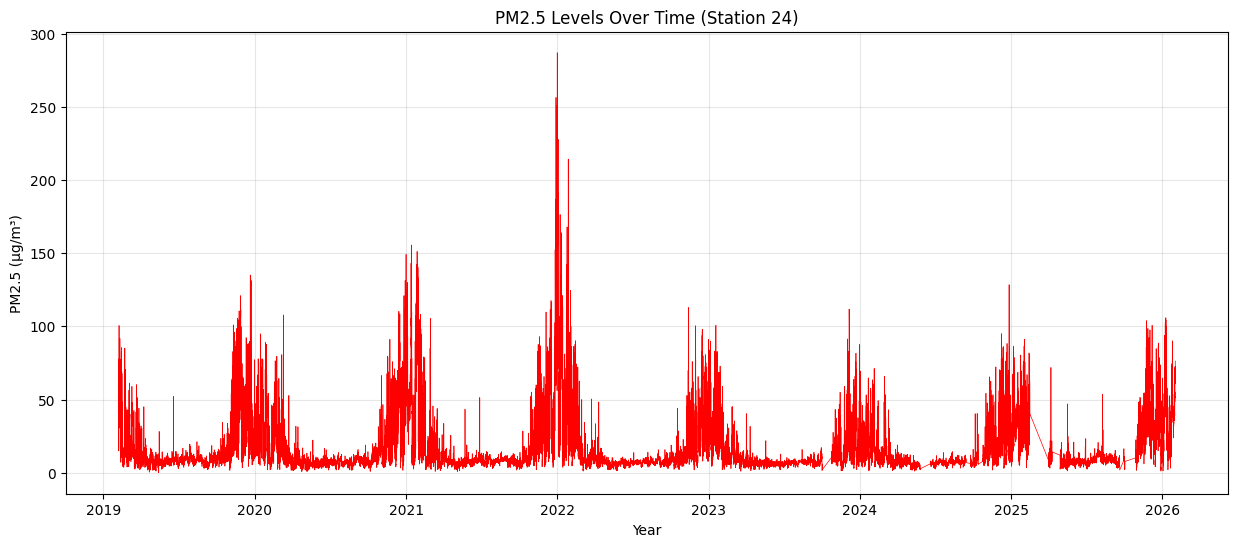

In [14]:
# Create a temporary table for just one station
single_station = df_yerevan[df_yerevan['station_id'] == top_station_id].copy()
single_station = single_station.sort_values('timestamp')

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(single_station['timestamp'], single_station['pm2.5'], color='red', linewidth=0.5)
plt.title(f"PM2.5 Levels Over Time (Station {top_station_id})")
plt.xlabel("Year")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
print("Highest PM2.5 values recorded:")
print(df_yerevan['pm2.5'].nlargest(10))

print("\nLowest PM2.5 values recorded (should not be negative):")
print(df_yerevan['pm2.5'].nsmallest(5))

Highest PM2.5 values recorded:
2498087    1126.8
2174951    1086.8
2508147     814.4
2171067     804.3
2454125     779.8
1750094     741.3
2388778     701.3
2171242     665.3
2340970     656.5
1749597     637.5
Name: pm2.5, dtype: float64

Lowest PM2.5 values recorded (should not be negative):
6329     0.0
30126    0.0
30144    0.0
30147    0.0
31488    0.0
Name: pm2.5, dtype: float64


In [22]:
# 1. Isolate Station 24
df_24 = df_yerevan[df_yerevan['station_id'] == 24].copy()
df_24 = df_24.sort_values('timestamp')

# 2. Outlier Handling: Cap PM2.5 at 500 (Anything higher is likely a glitch)
df_24.loc[df_24['pm2.5'] > 500, 'pm2.5'] = 500

# 3. Create a truly continuous hourly index (Temporal Alignment)
# This fills in hours where the sensor was OFF with 'NaN'
df_24 = df_24.set_index('timestamp').resample('H').asfreq().reset_index()

# 4. Interpolate small gaps (up to 3 hours)
df_24['pm2.5'] = df_24['pm2.5'].interpolate(method='linear', limit=3)

print(f"Station 24 processed. Total hourly slots: {len(df_24)}")

Station 24 processed. Total hourly slots: 61234


C:\Users\aregk\AppData\Local\Temp\ipykernel_14644\1692693665.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_24 = df_24.set_index('timestamp').resample('H').asfreq().reset_index()


In [23]:
# Create Lags - we use 1, 2, 3, and 24 hours
for i in [1, 2, 3, 24]:
    df_24[f'lag_{i}h'] = df_24['pm2.5'].shift(i)

# Create Time Features
df_24['hour'] = df_24['timestamp'].dt.hour
df_24['month'] = df_24['timestamp'].dt.month

# Create the TARGET (What we want to predict: pm2.5 in 1 hour)
df_24['target'] = df_24['pm2.5'].shift(-1)

# Drop rows where we don't have enough history or a future target
df_final = df_24.dropna(subset=['lag_24h', 'target'])

print("Feature Engineering Complete!")

Feature Engineering Complete!


In [24]:
# Split the data based on time
train = df_final[df_final['timestamp'] < '2025-01-01']
test = df_final[df_final['timestamp'] >= '2025-01-01']

# Define features - only using the ones we actually created
feature_cols = ['lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'hour', 'month']

X_train = train[feature_cols]
y_train = train['target']

X_test = test[feature_cols]
y_test = test['target']

# Fill any remaining gaps in features with the average value
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean()) 

print(f"Ready to model! Training on {len(X_train)} hours, Testing on {len(X_test)} hours.")

Ready to model! Training on 49457 hours, Testing on 6912 hours.


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Train Statistical Model (Linear Regression)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 2. Train Machine Learning Model (Random Forest)
# We use a small number of trees (n_estimators=50) to make it run faster for now
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 3. Compare Results
def get_metrics(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    print(f"--- {name} Results ---")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.2f}\n")

get_metrics(y_test, lr_preds, "Linear Regression (Statistical)")
get_metrics(y_test, rf_preds, "Random Forest (ML)")

--- Linear Regression (Statistical) Results ---
MAE: 4.24
RMSE: 7.72
R2: 0.83

--- Random Forest (ML) Results ---
MAE: 3.89
RMSE: 7.08
R2: 0.86



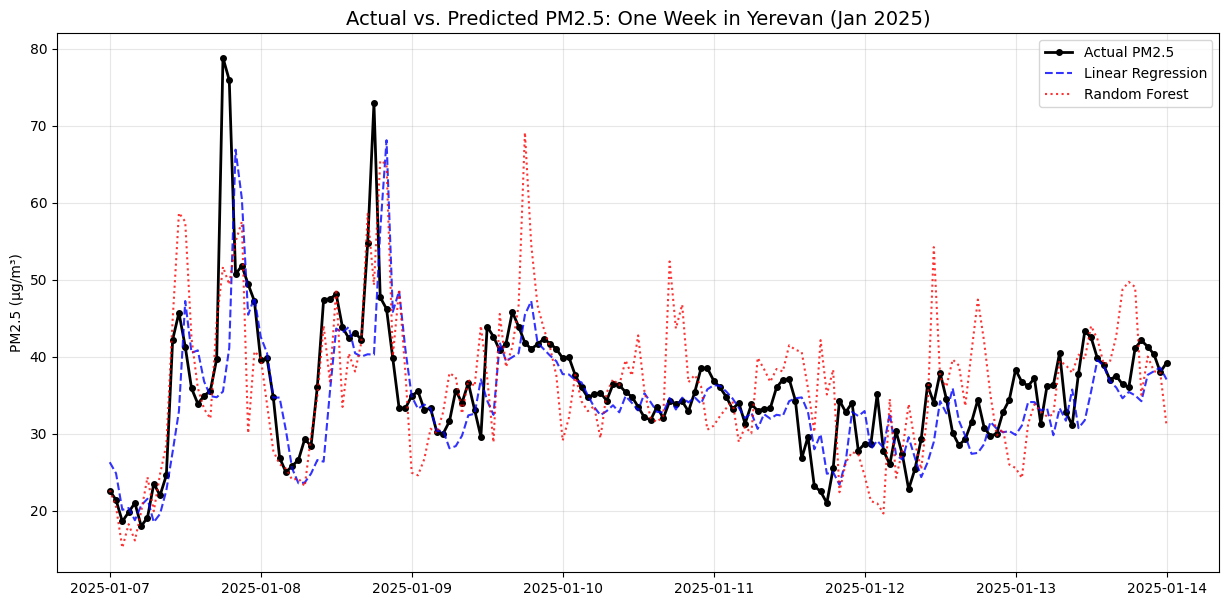

In [26]:
import matplotlib.pyplot as plt

# 1. Create a DataFrame for the test results
results = test[['timestamp', 'target']].copy()
results['Linear_Reg_Pred'] = lr_preds
results['Random_Forest_Pred'] = rf_preds

# 2. Pick a specific week in January 2025 to zoom in on (Winter is most interesting!)
week_sample = results[(results['timestamp'] >= '2025-01-07') & 
                     (results['timestamp'] <= '2025-01-14')]

# 3. Plot the comparison
plt.figure(figsize=(15, 7))
plt.plot(week_sample['timestamp'], week_sample['target'], label='Actual PM2.5', color='black', linewidth=2, marker='o', markersize=4)
plt.plot(week_sample['timestamp'], week_sample['Linear_Reg_Pred'], label='Linear Regression', color='blue', linestyle='--', alpha=0.8)
plt.plot(week_sample['timestamp'], week_sample['Random_Forest_Pred'], label='Random Forest', color='red', linestyle=':', alpha=0.8)

plt.title("Actual vs. Predicted PM2.5: One Week in Yerevan (Jan 2025)", fontsize=14)
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

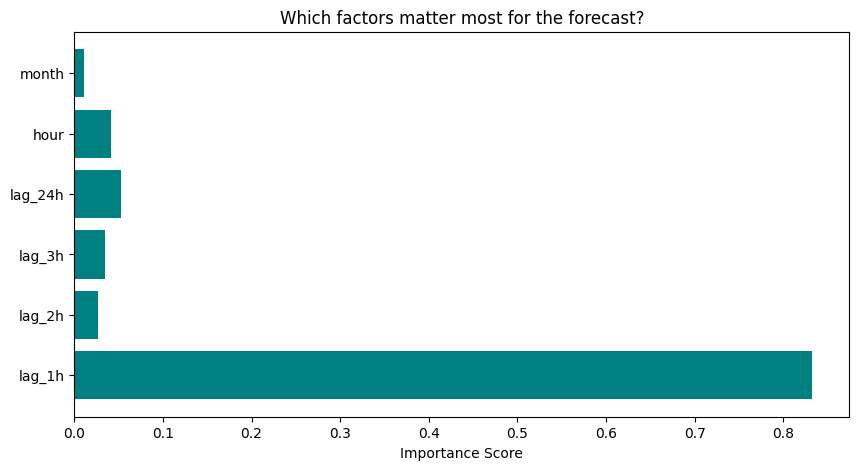

In [27]:
# Get feature importance from the Random Forest
importances = rf_model.feature_importances_
feature_names = feature_cols

# Plotting
plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances, color='teal')
plt.title("Which factors matter most for the forecast?")
plt.xlabel("Importance Score")
plt.show()

In [28]:
# 1. Start from our 'df_yerevan' master file
# Sort by station and time to keep sequences correct
df_city = df_yerevan.sort_values(['station_id', 'timestamp']).copy()

# 2. Outlier Handling: Cap PM2.5 for the whole city
df_city.loc[df_city['pm2.5'] > 500, 'pm2.5'] = 500

# 3. Apply Lags per station
# This is crucial: we don't want Station A's lag to be Station B's previous hour!
for i in [1, 2, 3, 24]:
    df_city[f'lag_{i}h'] = df_city.groupby('station_id')['pm2.5'].shift(i)

# 4. Add Time Features
df_city['hour'] = df_city['timestamp'].dt.hour
df_city['month'] = df_city['timestamp'].dt.month

# 5. Define the Target (PM2.5 in 1 hour)
df_city['target'] = df_city.groupby('station_id')['pm2.5'].shift(-1)

# 6. Drop empty rows (where lags or targets don't exist)
df_city_final = df_city.dropna(subset=['lag_24h', 'target'])

print(f"Full city dataset ready with {len(df_city_final)} rows across multiple sensors.")

Full city dataset ready with 1591937 rows across multiple sensors.


In [29]:
# Split the data
train_city = df_city_final[df_city_final['timestamp'] < '2025-01-01']
test_city = df_city_final[df_city_final['timestamp'] >= '2025-01-01']

feature_cols = ['lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'hour', 'month']

X_train_c, y_train_c = train_city[feature_cols].fillna(0), train_city['target']
X_test_c, y_test_c = test_city[feature_cols].fillna(0), test_city['target']

# 1. Linear Regression
lr_city = LinearRegression()
lr_city.fit(X_train_c, y_train_c)
lr_city_preds = lr_city.predict(X_test_c)

# 2. Random Forest
# Increased n_estimators because we have much more data now
rf_city = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_city.fit(X_train_c, y_train_c)
rf_city_preds = rf_city.predict(X_test_c)

# Metrics
get_metrics(y_test_c, lr_city_preds, "City-Wide Linear Regression")
get_metrics(y_test_c, rf_city_preds, "City-Wide Random Forest")

--- City-Wide Linear Regression Results ---
MAE: 7.05
RMSE: 14.12
R2: 0.85

--- City-Wide Random Forest Results ---
MAE: 6.53
RMSE: 13.45
R2: 0.87



In [30]:
!pip install xgboost

     -------------------------------------- 124.9/124.9 MB 3.2 MB/s eta 0:00:00


In [31]:
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor

# 1. XGBoost (Fast and very powerful for air quality)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train_c, y_train_c)
xgb_preds = xgb_model.predict(X_test_c)

# 2. Extra Trees (Often smoother than Random Forest)
et_model = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
et_model.fit(X_train_c, y_train_c)
et_preds = et_model.predict(X_test_c)

# 3. Print Results for the new models
get_metrics(y_test_c, xgb_preds, "City-Wide XGBoost")
get_metrics(y_test_c, et_preds, "City-Wide Extra Trees")

--- City-Wide XGBoost Results ---
MAE: 6.45
RMSE: 13.62
R2: 0.86

--- City-Wide Extra Trees Results ---
MAE: 6.63
RMSE: 13.49
R2: 0.86



In [32]:
import pandas as pd

summary_data = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "Extra Trees"],
    "MAE": [7.05, 6.53, mean_absolute_error(y_test_c, xgb_preds), mean_absolute_error(y_test_c, et_preds)],
    "R2": [0.85, 0.87, r2_score(y_test_c, xgb_preds), r2_score(y_test_c, et_preds)]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df)

               Model      MAE        R2
0  Linear Regression  7.05000  0.850000
1      Random Forest  6.53000  0.870000
2            XGBoost  6.44978  0.862151
3        Extra Trees  6.63346  0.864778
